# WikiArt EDA
Exploratory Data Analysis for the artist classification project.

In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

## 1. Dataset Overview

In [2]:
DATA_ROOT = pathlib.Path("../data/wikiart")

# Collect all images and their artist labels
records = []
for artist_dir in sorted(DATA_ROOT.iterdir()):
    if artist_dir.is_dir():
        for img_path in artist_dir.glob("*.jpg"):
            records.append({"filepath": str(img_path.relative_to(DATA_ROOT.parent)), "artist": artist_dir.name})

df = pd.DataFrame(records)
print(f"Total images : {len(df)}")
print(f"Unique artists: {df['artist'].nunique()}")
df.head()

Total images : 13340
Unique artists: 23


,filepath,artist
0,wikiart/Albrecht_Durer/albrecht-durer_seated-p...,Albrecht_Durer
1,wikiart/Albrecht_Durer/albrecht-durer_self-por...,Albrecht_Durer
2,wikiart/Albrecht_Durer/albrecht-durer_hercules...,Albrecht_Durer
3,wikiart/Albrecht_Durer/albrecht-durer_head-of-...,Albrecht_Durer
4,wikiart/Albrecht_Durer/albrecht-durer_portrait...,Albrecht_Durer


## 2. Class Distribution

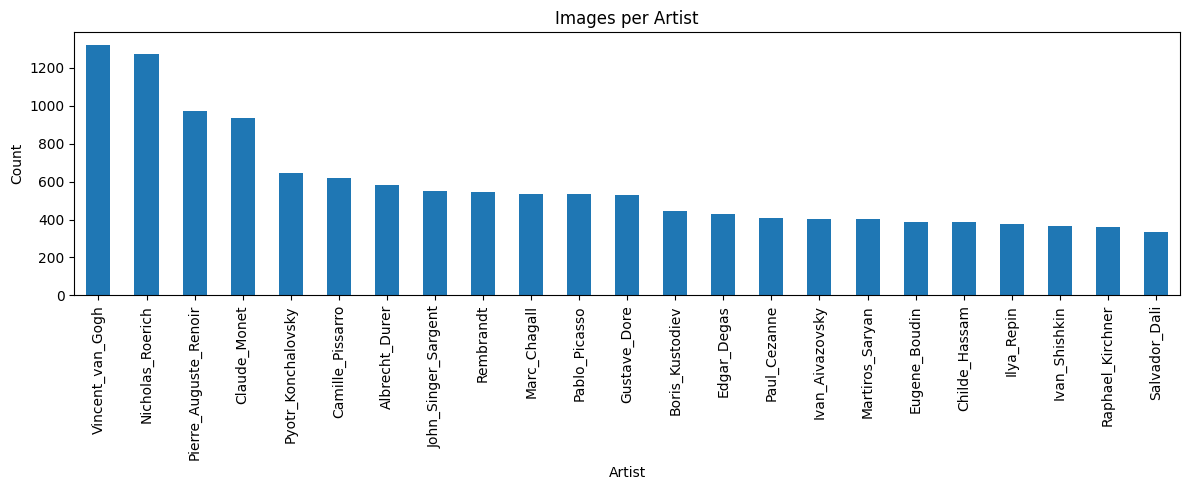

count      23.000000
mean      580.000000
std       280.546382
min       336.000000
25%       396.000000
50%       528.000000
75%       600.500000
max      1322.000000
Name: count, dtype: float64


In [3]:
counts = df["artist"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
counts.plot(kind="bar", ax=ax)
ax.set_title("Images per Artist")
ax.set_xlabel("Artist")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(counts.describe())

## 3. Image Dimensions

In [4]:
sample = df.sample(min(200, len(df)), random_state=42)
sizes = []
for fp in sample["filepath"]:
    try:
        with Image.open(DATA_ROOT.parent / fp) as img:
            sizes.append(img.size)  # (width, height)
    except Exception:
        pass

widths, heights = zip(*sizes)
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

Width  — min: 512, max: 512, mean: 512
Height — min: 512, max: 512, mean: 512


## 4. Sample Images

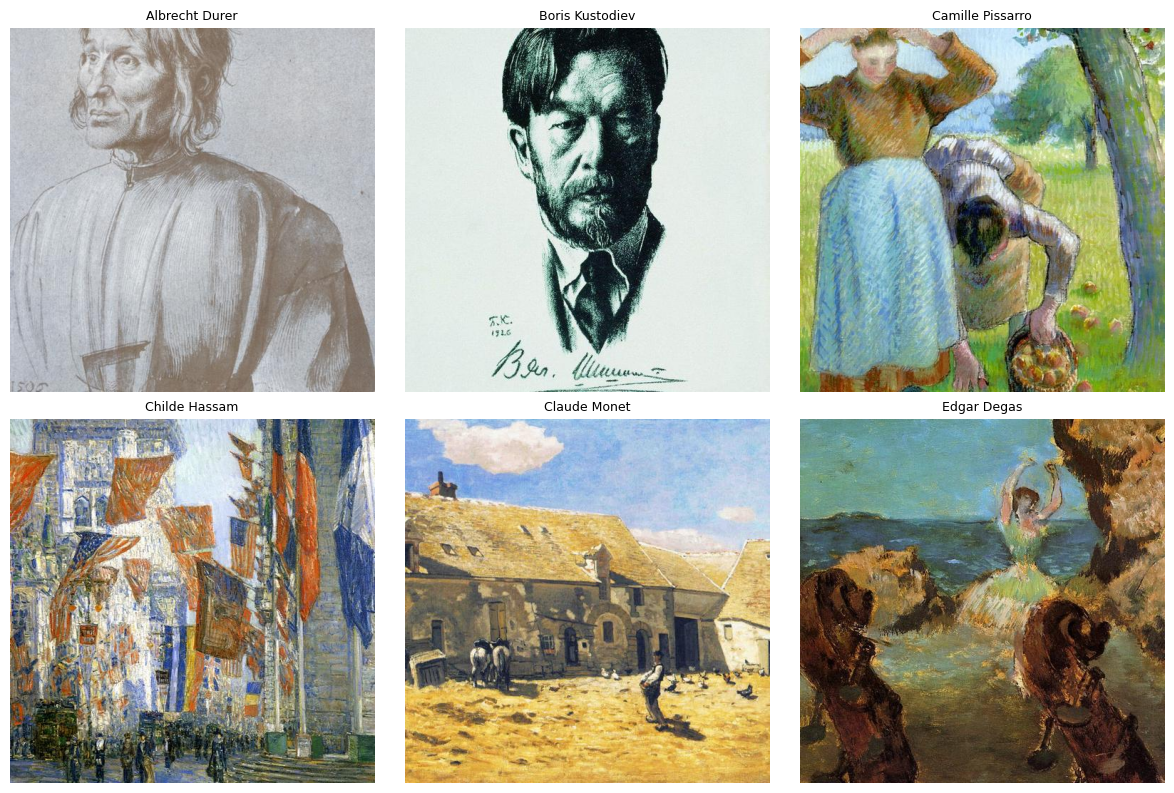

In [5]:
artists = df["artist"].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, artist in zip(axes.flat, artists):
    fp = df[df["artist"] == artist].sample(1).iloc[0]["filepath"]
    img = Image.open(DATA_ROOT.parent / fp).convert("RGB")
    ax.imshow(img)
    ax.set_title(artist.replace("_", " "), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()